In [1]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, GlobalAveragePooling2D, Input, Dropout
from tensorflow.keras.optimizers import Adam

#Load CIFAR-10 data
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

# Normalize data (0–255 → 0–1)
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# One-hot encode labels (10 classes)
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

print("Training data shape:", X_train.shape)
print("Test data shape:", X_test.shape)

#Load Pretrained MobileNetV2
base_model = MobileNetV2(weights="imagenet", include_top=False, input_shape=(32, 32, 3))

# Freeze base model layers (so we don’t retrain ImageNet weights)
base_model.trainable = False

#Add custom layers for CIFAR-10
#transfer learning as mobilenetv2 is a large dataset compared to cifar10
x = base_model.output
x = GlobalAveragePooling2D()(x)   # Reduce dimensions
x = Dropout(0.3)(x)               # Regularization
predictions = Dense(10, activation="softmax")(x)  # 10 classes for CIFAR-10

# Final model
model = Model(inputs=base_model.input, outputs=predictions)

#Compile
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss="categorical_crossentropy",
              metrics=["accuracy"])

#Evaluate
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"✅ Test accuracy: {test_acc:.4f}")


Training data shape: (50000, 32, 32, 3)
Test data shape: (10000, 32, 32, 3)


C:\Users\phane\AppData\Local\Temp\ipykernel_16616\1941983285.py:24: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights="imagenet", include_top=False, input_shape=(32, 32, 3))


✅ Test accuracy: 0.0926


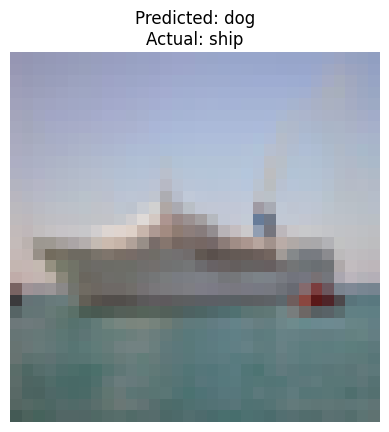

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# CIFAR-10 class names
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer','dog', 'frog', 'horse', 'ship', 'truck']

def predict_random_image(model, X_test, y_test):
    # Pick a random index
    idx = np.random.randint(0, X_test.shape[0])
    img = X_test[idx]
    true_label = np.argmax(y_test[idx])

    # Expand dims for model prediction
    img_input = np.expand_dims(img, axis=0)
    pred = model.predict(img_input, verbose=0)
    pred_label = np.argmax(pred)

    # Plot image
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Predicted: {class_names[pred_label]}\nActual: {class_names[true_label]}")
    plt.show()

# Example usage
predict_random_image(model, X_test, y_test)


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# CIFAR-10 class names
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer','dog', 'frog', 'horse', 'ship', 'truck']

def plot_confusion_matrix(model, X_test, y_test):
    y_pred = model.predict(X_test, verbose=0)
    y_pred_classes = np.argmax(y_pred, axis=1)
    y_true = np.argmax(y_test, axis=1)

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred_classes)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

    # Plot
    fig, ax = plt.subplots(figsize=(10, 8))
    disp.plot(cmap="Blues", ax=ax, xticks_rotation=45)
    plt.title("Confusion Matrix")
    plt.show()

    # Print report
    print("\nClassification Report:\n")
    print(classification_report(y_true, y_pred_classes, target_names=class_names))


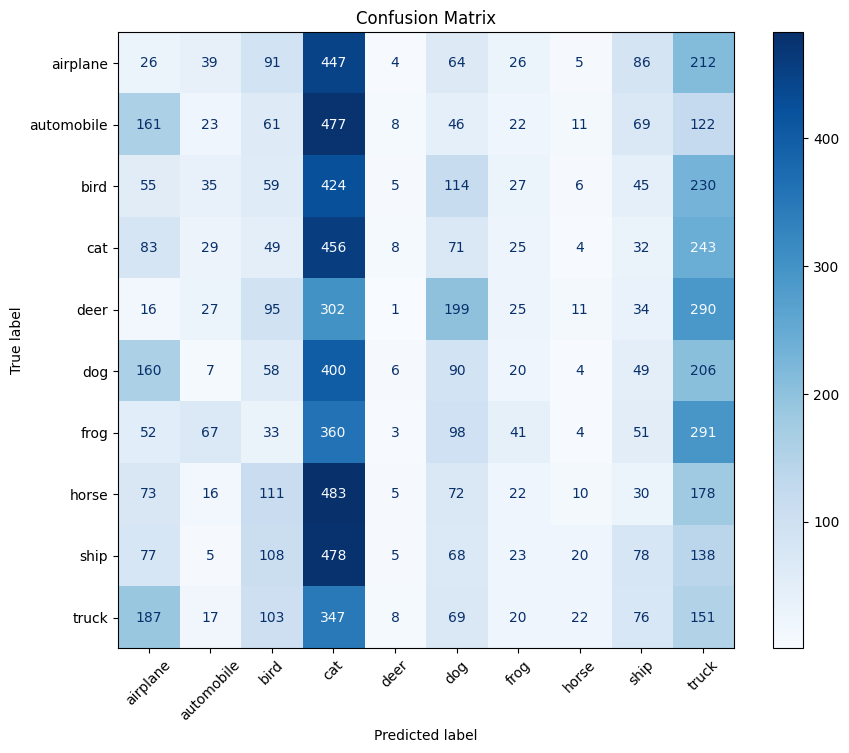


Classification Report:

              precision    recall  f1-score   support

    airplane       0.03      0.03      0.03      1000
  automobile       0.09      0.02      0.04      1000
        bird       0.08      0.06      0.07      1000
         cat       0.11      0.46      0.18      1000
        deer       0.02      0.00      0.00      1000
         dog       0.10      0.09      0.10      1000
        frog       0.16      0.04      0.07      1000
       horse       0.10      0.01      0.02      1000
        ship       0.14      0.08      0.10      1000
       truck       0.07      0.15      0.10      1000

    accuracy                           0.09     10000
   macro avg       0.09      0.09      0.07     10000
weighted avg       0.09      0.09      0.07     10000



In [27]:
plot_confusion_matrix(model, X_test, y_test)  # Show confusion matrix